### Robot Learning

### Assignment 5

Solutions are due on 02.06.2026 before the lecture.

### Team Info

1. Sayedmohammadreza Rastegari  
   Uni-mail: s64srast@uni-bonn.de

2. Rami Kallel  
   Uni-mail: s12rkall@uni-bonn.de

3. Azmat Ali Bakht
   Uni-mail: s24abakh@uni-bonn.de

### Introduction

Please carefully read the following description of the card game *Blackjack*.

The goal of Blackjack is to draw cards such that their values sum to as close to 21 as possible, but do not exceed 21. All cards 2 through 10 are assigned their number as the respective value, face cards like Jack, Queen and King yield a value of 10 points. The aces are special; they can count as either 1 or 11, depending on what is more beneficial. When using the ace as 11 points does not cause the total value of the hand to exceed 21, the ace is called 'usable'. 

The actions are to *stick*, which means to stop drawing cards and let the dealer play, or to *hit*, which means to draw another card to add to your hand. 

The opponent is a dealer with a fixed strategy; the dealer will always hit when the dealer's sum of card values is below 17 points. At or above 17 points, the dealer immediately sticks, irrespective of the player's card sum. Note that the dealer only starts playing once the player is finished, so when the player has selected to stick.

The game starts by drawing two cards each to player and dealer from an infinite deck. The player can see the own cards, but only the first card which the dealer recieves, the other is face-down. If the player hits and exceeds 21 points, the player is considered *bust* and immediately loses the game. When the player decides to stick, the dealer will draw cards according to its strategy. If the dealer goes *bust* in the process, the player immediately wins the game. If not, the sum of the dealer's card values is compared to the sum of the player's card values. If they are equal, the game is considered a draw. If the player has a higher score, the player wins, and vice versa.

In this RL setting, the rewards are +1 for winning, -1 for losing, and 0 for drawing and all intermediate moves. The state is a 3-tuple consisting of the players current hand sum, the value of the dealer's initial open card and a boolean describing whether the player currently has a usable ace or not. The action space consists of the integer $0$, which corresponds to *stick*, and the integer $1$, which corresponds to *hit*. Note that this corresponds exactly to the scenario described in *Example 5.1; Reinforcement Learning: An Introduction; Sutton and Barto*.

To get started, please examine the following code cell, which loads the Blackjack environment from the utils file and plays an episode. The player is in this case the random agent. The environment is equivalent to the one provided in OpenAI Gym; we adapted the source code so that installing this python package is not necessary.

In [1]:
import numpy as np
from helpers.utils import BlackjackEnv

np.random.seed(42)
# create a Blackjack environment
casino = BlackjackEnv()

# do this before each new episode
# state is 3-tuple: (player_current_sum, dealer_first_open_card, usable_ace_bool)
# if dealer_first_open_card == 1, the dealer is holding an ace!
starting_state = casino.reset()

# create flag tracking whether the episode is over
done = False

# create lists to save the trajectory and the decisions of the agent
actions, rewards, states = [], [], [starting_state]

# simulate until the episode is over
while not done:
    #in each non-terminal state the agent can either stick (0) or hit (1)
    possibleActions = casino.getAvailableActions()
    # select one of them randomly
    a = np.random.choice(possibleActions).item()
    # save the action
    actions.append(a)
    # execute the action using the step function
    # s is the new state
    # done is the flag whether the episode is over
    # the fourth output _ is a dict containing additional information on the environment
    # it is empty here, but passing it is according to convention in OpenAI Gym environments
    s, r, done, _ = casino.step(action = a)
    # save the states
    rewards.append(r)
    states.append(s)
    
print('Action Sequence:', actions)
print('Obtained Rewards:', rewards)
print('State Transitions:', states)

Action Sequence: [1, 0]
Obtained Rewards: [0.0, -1.0]
State Transitions: [(12, 8, 0), (15, 8, 0), (15, 8, 0)]


### Task 5.1)

Implement Sarsa($\lambda$) for Blackjack. Use an $\varepsilon$-greedy exploration strategy with $\varepsilon = 0.08$ and a time-varying scalar step-size of $\alpha_t = \frac{1}{N(s_t,a_t)+1}$, where $N(s, a)$ is the number of times the value of this state-action pair has been updated.

Run the algorithm with parameter values $\lambda \in \{0, 0.1, 0.2, \dots, 1\}$. Stop exploration and learning
after $100000$ episodes and plot the average return for the next $10000$ episodes against $\lambda$. 

Note that there is a loop over all state-actions pairs in the Sarsa($\lambda$) algorithm. This loop is straightforward (but also necessary) to vectorize. Do not hesitate to contact your tutors if you need help with this step. Also, the random agent scores around $-0.4$ on average, and your trained agents should be able to outperform this weak baseline.

<div style="text-align: right; font-weight:bold"> 5 Points </div>

lambda=0.0  avg return = -0.0597
lambda=0.1  avg return = -0.0558
lambda=0.2  avg return = -0.0510
lambda=0.3  avg return = -0.0463
lambda=0.4  avg return = -0.0619
lambda=0.5  avg return = -0.0565
lambda=0.6  avg return = -0.0535
lambda=0.7  avg return = -0.0758
lambda=0.8  avg return = -0.0452
lambda=0.9  avg return = -0.0774
lambda=1.0  avg return = -0.0609


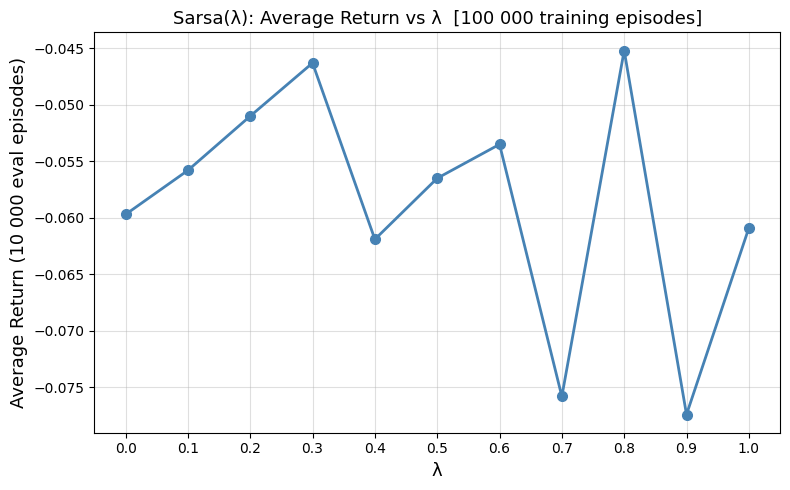

In [ ]:
# your code goes here
import matplotlib.pyplot as plt
def sarsa_lambda(env, lam, n_train=100_000, n_eval=10_000, eps=0.08):
    Q = np.zeros((32, 11, 2, 2))          # action-value table
    N = np.zeros((32, 11, 2, 2), dtype=int)  # visit count for step size

    def policy(s, greedy=False):
        ps, dc, ua = s
        if not greedy and np.random.random() < eps:
            return np.random.randint(2)
        return int(np.argmax(Q[ps, dc, ua]))

    # --- Training ---
    for _ in range(n_train):
        s = env.reset()
        a = policy(s)
        E = np.zeros_like(Q)   # eligibility trace, reset each episode
        done = False

        while not done:
            ps, dc, ua = s
            s_next, r, done, _ = env.step(a)
            a_next = policy(s_next) if not done else 0

            # TD error delta
            ps2, dc2, ua2 = s_next
            q_next = 0.0 if done else Q[ps2, dc2, ua2, a_next]
            delta = r + q_next - Q[ps, dc, ua, a]

            # Time-varying step size
            N[ps, dc, ua, a] += 1
            alpha = 1.0 / (N[ps, dc, ua, a] + 1)

            # Accumulating eligibility trace
            E[ps, dc, ua, a] += 1.0

            # Vectorised update of all (s, a) pairs
            Q   += alpha * delta * E
            E   *= lam               # decay traces

            s, a = s_next, a_next

    # --- Evaluation (greedy, no learning) ---
    returns = []
    for _ in range(n_eval):
        s = env.reset()
        done = False
        ep_return = 0.0
        while not done:
            a = policy(s, greedy=True)
            s, r, done, _ = env.step(a)
            ep_return += r
        returns.append(ep_return)

    return Q, np.mean(returns)


# Run sweep
lambdas = np.round(np.arange(0, 1.1, 0.1), 2)
avg_returns = []

for lam in lambdas:
    env = BlackjackEnv()
    Q, avg = sarsa_lambda(env, lam=lam, n_train=100_000, n_eval=10_000)
    avg_returns.append(avg)
    print(f"lambda={lam:.1f}  avg return = {avg:.4f}")

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lambdas, avg_returns, 'o-', color='steelblue', linewidth=2, markersize=7)
plt.xlabel("λ", fontsize=13)
plt.ylabel("Average Return (10 000 eval episodes)", fontsize=13)
plt.title("Sarsa(λ): Average Return vs λ  [100 000 training episodes]", fontsize=13)
plt.grid(True, alpha=0.4)
plt.xticks(lambdas)
plt.tight_layout()
plt.show()

### Task 5.2)

Use your experiment from task 5.1) to select your favorite value for $\lambda$. Learn $Q$ using the Sarsa($\lambda$) algorithm for $1$ million episodes. After training, stop exploration and learning and report the average return for the next $10000$ episodes. Finally, visualize the resulting policy by using the helper function *plotPolicy(Q)*.

<div style="text-align: right; font-weight:bold"> 2 Points </div>

Best lambda = 0.8
Average return after 1M training episodes: -0.0554


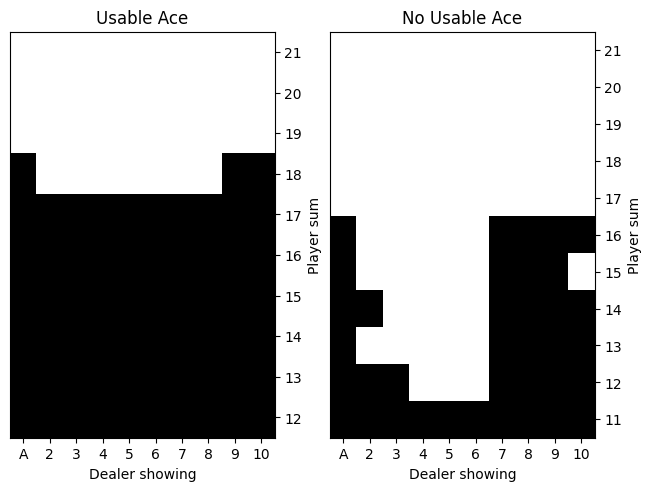

In [4]:
from helpers.utils import plotPolicy
# your code goes here
best_lam = lambdas[np.argmax(avg_returns)]
print(f"Best lambda = {best_lam}")

# Train for 1 million episodes
env = BlackjackEnv()
Q_best, avg_52 = sarsa_lambda(env, lam=best_lam, n_train=1_000_000, n_eval=10_000)
print(f"Average return after 1M training episodes: {avg_52:.4f}")

# Visualise the greedy policy
# Black = HIT, White = STICK
plotPolicy(Q_best)

### Task 5.3)

Now consider a simple coarse coding value function approximator that is based on a binary feature vector $\phi_{s, a} \in \mathbb{R}^{128}$ with $8 \times 4 \times 2 \times 2 = 128$ features. Each binary feature has a value of 1 iff $(s, a)$ lies within the cuboid of state-action-space corresponding to that feature. The cuboids have the following overlapping intervals:

$player(s) = \{[4, 7], [6, 9], [8, 11], [10, 13], [12, 15], [14, 17], [18, 20], [19, 21]\}$

$dealer(s) = \{[1,4], [3, 6], [5, 8], [7, 10]\}$

$usable\_ace(s) = \{0,1\}$

$a = \{0, 1\}$

where

* player(s) is the sum of the player’s cards (4–21) in state s
* dealer(s) is the value of the dealer’s first card (1–10) in state s

Implement a function $phi(s,a)$ which takes a state-action pair $(s,a)$ and maps it to a vector $\phi_{s,a}$ as described above.

<div style="text-align: right; font-weight:bold"> 3 Points </div>

In [ ]:
# your code goes here
# Intervals as specified in the assignment
player_intervals = [(4,7), (6,9), (8,11), (10,13), (12,15), (14,17), (18,20), (19,21)]
dealer_intervals = [(1,4), (3,6), (5,8), (7,10)]
# usable_ace in {0, 1}, action in {0, 1}

def phi(s, a):
    player_sum, dealer_card, usable_ace = s
    feat = np.zeros(128, dtype=float)
    idx = 0
    for plo, phi_hi in player_intervals:          # 8 intervals
        for dlo, dhi in dealer_intervals:          # 4 intervals
            for ace in (0, 1):                     # 2 ace values
                for act in (0, 1):                 # 2 actions
                    if (plo <= player_sum  <= phi_hi and
                        dlo <= dealer_card <= dhi   and
                        usable_ace == ace            and
                        a          == act):
                        feat[idx] = 1.0
                    idx += 1
    return feat

# Sanity checks
s_test = (15, 6, 0)
print(f"phi((15,6,0), 0): length={len(phi(s_test,0))}, active features={int(phi(s_test,0).sum())}")
print(f"phi((15,6,0), 1): length={len(phi(s_test,1))}, active features={int(phi(s_test,1).sum())}")


phi((15,6,0), 0): length=128, active features=4
phi((15,6,0), 1): length=128, active features=4


### Task 5.4)

Conduct one more Sarsa($\lambda$) experiment, but this time use a linear value function approximation $Q(s,a) = \theta \cdot \phi_{s,a}$. Use a constant exploration of $\varepsilon=0.08$, a constant step-size of $\alpha=0.12$ and your favorite $\lambda$.

Stop exploration and learning after $200000$ episodes and report the average return for the next $10000$ episodes.

To clarify, $\theta$ is a row vector which your algorithm learns instead of $Q(s,a)$. The row vector times column vector product $Q(s,a) = \theta \cdot \phi_{s,a}$ can also be understood as $Q(s,a) = \sum_{i=0}^{127} \theta(i)\phi_{s,a}(i)$.

<div style="text-align: right; font-weight:bold"> 4 Points </div>

In [ ]:
# your code goes here
def sarsa_lambda_linear(env, lam, n_train=200_000, n_eval=10_000, eps=0.08, alpha=0.12):
    theta = np.zeros(128)    # weight vector

    def Q_approx(s, a):
        return theta @ phi(s, a)

    def policy(s, greedy=False):
        if not greedy and np.random.random() < eps:
            return np.random.randint(2)
        # argmax over actions {0, 1}
        return 1 if Q_approx(s, 1) > Q_approx(s, 0) else 0

    # --- Training ---
    for _ in range(n_train):
        s  = env.reset()
        a  = policy(s)
        e  = np.zeros(128)    # eligibility trace vector
        done = False

        while not done:
            phi_sa = phi(s, a)
            s_next, r, done, _ = env.step(a)
            a_next = policy(s_next) if not done else 0

            # TD error
            q_next = 0.0 if done else theta @ phi(s_next, a_next)
            delta  = r + q_next - (theta @ phi_sa)

            # Eligibility trace update
            e = lam * e + phi_sa

            # Weight update
            theta += alpha * delta * e

            s, a = s_next, a_next

    # --- Evaluation ---
    returns = []
    for _ in range(n_eval):
        s = env.reset(); done = False; ep_return = 0.0
        while not done:
            a = policy(s, greedy=True)
            s, r, done, _ = env.step(a)
            ep_return += r
        returns.append(ep_return)

    return theta, np.mean(returns)


env = BlackjackEnv()
theta_final, avg_54 = sarsa_lambda_linear(env, lam=best_lam)
print(f"Linear Sarsa(lambda={best_lam}), 200K episodes")
print(f"Average return: {avg_54:.4f}")

Linear Sarsa(lambda=0.8), 200K episodes
Average return: -0.0804


### Task 5.5)

Implement the actor-critic version of TD(0) control. You can proceed as described on slide 4 in lecture 05. However, please adjust the update of the preferences $p(s,a)$ to

$$p[s_t][a_t] \leftarrow p[s_t][a_t] + \beta \delta_t [1 - \pi(s,a_t)]$$

This represents the learning rule for the actor. For the critic, you can update state values $V(s_t)$ according to

$$V(s_t) \leftarrow V(s_t) + \alpha \delta_t$$ 

after updating the actor for each step of the episode. Use $\alpha = \beta = 0.1$ and $\gamma = 0.99$ and learn for 1 million episodes. Report the mean return of the final $10000$ episodes.

Then, visualize the policy induced by $p$. It is possible to use *plotPolicy($\pi$)* for this purpose.

<div style="text-align: right; font-weight:bold"> 6 Points </div>

Actor-Critic TD(0), 1M episodes
Average return: -0.0620


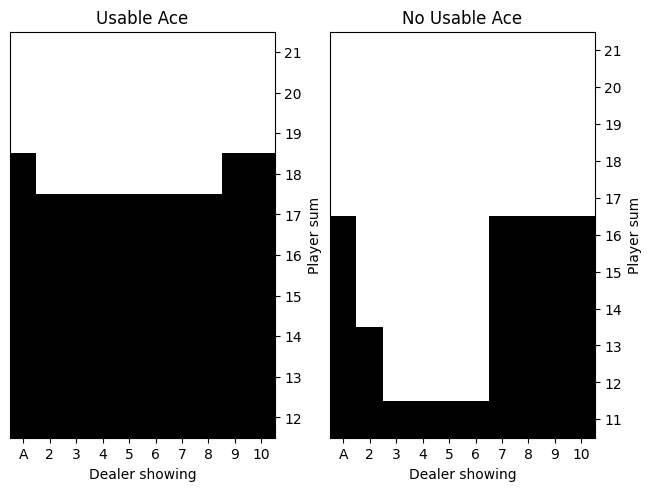

In [ ]:
# your code goes here
def actor_critic(env, n_train=1_000_000, n_eval=10_000,
                 alpha=0.1, beta=0.1, gamma=0.99):
    p = np.zeros((32, 11, 2, 2))   # preferences (actor)
    V = np.zeros((32, 11, 2))      # state values (critic)

    def softmax_policy(ps, dc, ua):
        prefs = p[ps, dc, ua]
        prefs_shifted = prefs - prefs.max()   # numerical stability
        exp_p = np.exp(prefs_shifted)
        return exp_p / exp_p.sum()

    def select_action(s):
        ps, dc, ua = s
        probs = softmax_policy(ps, dc, ua)
        return int(np.random.choice(2, p=probs))

    # --- Training ---
    for _ in range(n_train):
        s = env.reset()
        done = False

        while not done:
            ps, dc, ua = s
            a = select_action(s)
            s_next, r, done, _ = env.step(a)
            ps2, dc2, ua2 = s_next

            # TD error (critic)
            v_next = 0.0 if done else V[ps2, dc2, ua2]
            delta  = r + gamma * v_next - V[ps, dc, ua]

            # Critic update
            V[ps, dc, ua] += alpha * delta

            # Actor update  (as specified in the assignment)
            probs = softmax_policy(ps, dc, ua)
            p[ps, dc, ua, a] += beta * delta * (1.0 - probs[a])

            s = s_next

    # --- Evaluation (greedy: pick most probable action) ---
    returns = []
    for _ in range(n_eval):
        s = env.reset(); done = False; ep_return = 0.0
        while not done:
            ps, dc, ua = s
            probs = softmax_policy(ps, dc, ua)
            a = int(np.argmax(probs))
            s, r, done, _ = env.step(a)
            ep_return += r
        returns.append(ep_return)

    return p, V, np.mean(returns)


env = BlackjackEnv()
p_final, V_final, avg_55 = actor_critic(env)
print(f"Actor-Critic TD(0), 1M episodes")
print(f"Average return: {avg_55:.4f}")

# Visualise policy induced by p (same plotPolicy helper, p plays role of Q)
plotPolicy(p_final)